In [3]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import math

import os
from sklearn.preprocessing import MinMaxScaler, StandardScaler 
from sklearn.model_selection import train_test_split
import re
import json

In [4]:
MAX_LEN = 128
BATCH_SIZE = 64
EMB_DIM = 256
LATENT_DIM = 128
N_HEADS = 8
FF_DIM = 512
NUM_LAYERS = 4
VOCAB_SPECIAL = ['<pad>', '<bos>', '<eos>', '<unk>']

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {DEVICE}")
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

Используем устройство: cuda
True
12.8
NVIDIA GeForce RTX 3060 Laptop GPU


In [5]:
# Загружаем датасет
df = pd.read_csv("../data/raw/polyOne_aa.csv")

with open("../data/configs/property_mapping.json", "r", encoding="utf-8") as f:
    json_data = json.load(f)
    PROPERTY_MAPPING = json_data["PROPERTY_MAPPING"] 

# Теперь NUM_FEATURES будет содержать все ключи из PROPERTY_MAPPING
NUM_FEATURES = list(PROPERTY_MAPPING.keys())
print(f"Количество признаков: {len(NUM_FEATURES)}")
print(NUM_FEATURES[:5])  # Показываем первые 5 признаков для проверки

Количество признаков: 37
['Egc', 'Egb', 'Eib', 'CED', 'Ei']


In [6]:
class PolymerDataset(Dataset):
    def __init__(self, df, tokenizer, property_cols, scaler=None, fit_scaler=False, augment=False):
        self.tokenizer = tokenizer
        self.property_cols = property_cols
        self.smiles = df['smiles'].tolist()
        self.augment = augment  # Флаг для включения аугментации (только для Train)

        # Извлекаем свойства
        self.properties = df[property_cols].values.astype(np.float32)
        
        # Маска: 1 где есть данные, 0 где NaN
        self.mask = ~np.isnan(self.properties)
        filled_props = np.nan_to_num(self.properties, nan=0.0)

        if fit_scaler:
            self.scaler = StandardScaler()
            data_list = []
            for i in range(self.properties.shape[1]):
                col_data = self.properties[:, i]
                valid_col = col_data[~np.isnan(col_data)]
                data_list.append(valid_col)
            
            # Вручную задаем mean и scale
            self.scaler.mean_ = np.array([np.mean(d) for d in data_list])
            self.scaler.scale_ = np.array([np.std(d) for d in data_list])
            # Защита от деления на 0, если std=0
            self.scaler.scale_[self.scaler.scale_ == 0] = 1.0
            self.scaler.var_ = self.scaler.scale_ ** 2
            self.scaler.n_features_in_ = len(property_cols)
        else:
            self.scaler = scaler

        # Применяем нормализацию: (X - mean) / std
        if self.scaler is not None:
            # Ручная нормализация с учетом NaN (чтобы NaN остались NaN или нулями)
            self.properties = (self.properties - self.scaler.mean_) / self.scaler.scale_
            self.properties = np.nan_to_num(self.properties, nan=0.0) # Теперь нули это "среднее"
        
    def _augment_smiles(self, smiles):
        """Генерирует случайный неканонический SMILES для той же молекулы"""
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None: return smiles
            # doRandom=True генерирует разные варианты строки
            return Chem.MolToSmiles(mol, canonical=False, doRandom=True, isomericSmiles=False)
        except:
            return smiles

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smiles = self.smiles[idx]
        
        # АУГМЕНТАЦИЯ: В 50% случаев меняем представление SMILES для тренировки
        if self.augment and np.random.rand() > 0.5:
            smiles = self._augment_smiles(smiles)
            
        encoded = self.tokenizer.encode(smiles)

        return {
            'input_ids': torch.tensor(encoded, dtype=torch.long),
            'properties': torch.tensor(self.properties[idx], dtype=torch.float32),
            'mask': torch.tensor(self.mask[idx], dtype=torch.bool)
        }

In [7]:
class SmilesTokenizer:
    """Токенизатор для SMILES строк с поддержкой специальных токенов"""

    SMILES_REGEX = r'(\[[^\]]+\]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])'

    def __init__(self, max_len=128):
        self.max_len = max_len
        self.regex = re.compile(self.SMILES_REGEX)
        self.vocab = {}
        self.inv_vocab = {}
        self._init_special_tokens()

    def _init_special_tokens(self):
        """Инициализация специальных токенов"""
        for i, token in enumerate(VOCAB_SPECIAL):
            self.vocab[token] = i
            self.inv_vocab[i] = token

    def fit(self, smiles_list):
        """Построение словаря на основе списка SMILES"""
        all_tokens = set()
        for smiles in smiles_list:
            tokens = self.regex.findall(smiles)
            all_tokens.update(tokens)

        # Добавляем токены в словарь
        idx = len(self.vocab)
        for token in sorted(all_tokens):
            if token not in self.vocab:
                self.vocab[token] = idx
                self.inv_vocab[idx] = token
                idx += 1

        print(f"Словарь построен: {len(self.vocab)} токенов")
        return self

    def tokenize(self, smiles):
        """Токенизация SMILES строки"""
        return self.regex.findall(smiles)

    def encode(self, smiles):
        # Добавляем BOS и EOS токены
        smiles = f"<bos>{smiles}<eos>"
        tokens = self.tokenize(smiles)

        # Используем <unk> для неизвестных токенов
        ids = []
        for t in tokens:
            # Получаем ID и конвертируем в целое число
            token_id = self.vocab.get(t, self.vocab['<unk>'])
            if torch.is_tensor(token_id):
                token_id = token_id.item()
            elif isinstance(token_id, (np.ndarray, list, tuple)):
                token_id = int(token_id[0]) if len(token_id) > 0 else 0
            ids.append(int(token_id))

        # Обрезаем или дополняем до MAX_LEN
        if len(ids) > self.max_len:
            ids = ids[:self.max_len]
        else:
            pad_id = self.vocab['<pad>']
            if torch.is_tensor(pad_id):
                pad_id = pad_id.item()
            elif isinstance(pad_id, (np.ndarray, list, tuple)):
                pad_id = int(pad_id[0]) if len(pad_id) > 0 else 0
            ids += [int(pad_id)] * (self.max_len - len(ids))

        return ids

    def decode(self, ids, skip_special=True):
        """Декодирование индексов обратно в SMILES"""
        tokens = [self.inv_vocab.get(i, '') for i in ids]

        if skip_special:
            tokens = [t for t in tokens if t not in VOCAB_SPECIAL]

        return ''.join(tokens)

    def save(self, path):
        """Сохранение токенизатора"""
        with open(path, 'w') as f:
            json.dump({'vocab': self.vocab, 'max_len': self.max_len}, f)

    @classmethod
    def load(cls, path):
        """Загрузка токенизатора"""
        with open(path, 'r') as f:
            data = json.load(f)
        tokenizer = cls(max_len=data['max_len'])
        tokenizer.vocab = data['vocab']
        tokenizer.inv_vocab = {int(v): k for k, v in data['vocab'].items()}
        return tokenizer

In [8]:
# Создаем и обучаем токенизатор
tokenizer = SmilesTokenizer(max_len=MAX_LEN)
tokenizer.fit(df['smiles'].tolist())
VOCAB_SIZE = len(tokenizer.vocab)
print(f"Размер словаря: {VOCAB_SIZE}")

Словарь построен: 61 токенов
Размер словаря: 61


In [9]:
# Разделяем данные
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Создаем датасеты
# Train с аугментацией
train_dataset = PolymerDataset(train_df, tokenizer, NUM_FEATURES, fit_scaler=True, augment=True)
# Val/Test без аугментации
val_dataset = PolymerDataset(val_df, tokenizer, NUM_FEATURES, scaler=train_dataset.scaler, augment=False)
test_dataset = PolymerDataset(test_df, tokenizer, NUM_FEATURES, scaler=train_dataset.scaler)

# Создаем DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

Train: 400000, Val: 50000, Test: 50000


In [10]:
class PositionalEncoding(nn.Module):
    """Синусоидальное позиционное кодирование"""
    
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

In [11]:
class AttentionPooling(nn.Module):
    """Взвешивает токены на основе их важности"""
    def __init__(self, emb_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.Tanh(),
            nn.Linear(emb_dim // 2, 1)
        )

    def forward(self, x, mask=None):
        w = self.attention(x)
        if mask is not None:
            # Заполняем padding очень маленьким числом перед softmax
            mask_expanded = mask.unsqueeze(-1) 
            w = w.masked_fill(~mask_expanded, -1e4) 
        
        weights = torch.softmax(w, dim=1)
        return torch.sum(x * weights, dim=1)

In [12]:
class SmilesPropertyPredictor(nn.Module):
    def __init__(self, vocab_size, num_properties, emb_dim=256, n_heads=8, ff_dim=512, num_layers=4, dropout=0.1, max_len=128):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.pos_encoding = PositionalEncoding(emb_dim, max_len, dropout)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.ln = nn.LayerNorm(emb_dim)
        
        # ЗАМЕНА: Attention Pooling вместо Mean Pooling
        self.pooler = AttentionPooling(emb_dim)
        
        # ЗАМЕНА: Убран Sigmoid в конце
        self.property_head = nn.Sequential(
            nn.Linear(emb_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, ff_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim // 2, num_properties)
            # НЕТ SIGMOID! Мы предсказываем Z-score
        )
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, input_ids, attention_mask=None):
        if attention_mask is None:
            attention_mask = (input_ids != 0)
        
        src_key_padding_mask = ~attention_mask # True где padding для TransformerEncoder
        
        x = self.embedding(input_ids)
        x = self.pos_encoding(x)
        
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        x = self.ln(x)
        
        # Используем attention mask для пулинга (True где данные)
        x = self.pooler(x, mask=attention_mask)
        
        properties = self.property_head(x)
        return properties

In [13]:
# Создаем модель
model = SmilesPropertyPredictor(
    vocab_size=VOCAB_SIZE,
    num_properties=len(NUM_FEATURES),
    emb_dim=EMB_DIM,
    n_heads=N_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout=0.1,
    max_len=MAX_LEN
).to(DEVICE)

model = model.to(DEVICE)  # <-- ДОБАВЬТЕ ЭТУ СТРОКУ
print(f"Модель перемещена на: {next(model.parameters()).device}")
print(f"Модель на устройстве: {next(model.parameters()).device}")
print(f"GPU память выделено: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

# Проверка памяти GPU
if DEVICE.type == 'cuda':
    print(f"Использовано GPU памяти: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
    
# Подсчет параметров
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Модель перемещена на: cuda:0
Модель на устройстве: cuda:0
GPU память выделено: 0.01 GB
Использовано GPU памяти: 0.01 GB
Всего параметров: 2,429,990
Обучаемых параметров: 2,429,990


C:\drivers\python_inter\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [14]:
class MaskedL1Loss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, predictions, targets, mask):
        # L1 (MAE) Loss
        absolute_error = torch.abs(predictions - targets)
        masked_error = absolute_error * mask.float()
        loss = masked_error.sum() / mask.float().sum().clamp(min=1)
        return loss

In [15]:
def train_epoch(model, loader, optimizer, criterion, scheduler=None, scaler=None):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    num_batches = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for batch in pbar:
        input_ids = batch['input_ids'].to(DEVICE)
        properties = batch['properties'].to(DEVICE)
        mask = batch['mask'].to(DEVICE)
        
        optimizer.zero_grad()
        
        # Mixed Precision Training
        if scaler is not None:
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                predictions = model(input_ids)
                loss = criterion(predictions, properties, mask)
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            predictions = model(input_ids)
            loss = criterion(predictions, properties, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        if scheduler is not None:
            scheduler.step()
        
        total_loss += loss.item()
        num_batches += 1
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / num_batches

In [16]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    """Оценка модели с минимальным переносом на CPU"""
    model.eval()
    device = next(model.parameters()).device
    
    total_loss = 0.0
    num_batches = 0
    
    all_preds = []
    all_targets = []
    all_masks = []
    
    for batch in tqdm(loader, desc="Evaluating", leave=False):
        input_ids = batch['input_ids'].to(device)
        properties = batch['properties'].to(device)
        mask = batch['mask'].to(device)
        
        predictions = model(input_ids)
        loss = criterion(predictions, properties, mask)
        
        total_loss += loss.item()
        num_batches += 1
        
        # Собираем всё на GPU
        all_preds.append(predictions)
        all_targets.append(properties)
        all_masks.append(mask)
    
    # Конкатенируем на GPU
    preds = torch.cat(all_preds, dim=0)
    targets = torch.cat(all_targets, dim=0)
    masks = torch.cat(all_masks, dim=0)
    
    # Вычисляем R2 на GPU
    r2_scores = {}
    avg_r2 = 0.0
    
    for i, prop in enumerate(NUM_FEATURES):
        valid_mask = masks[:, i].bool()
        if valid_mask.sum() > 1:  # Нужно минимум 2 валидных значения
            p = preds[:, i][valid_mask]
            t = targets[:, i][valid_mask]
            
            ss_res = torch.sum((t - p) ** 2)
            ss_tot = torch.sum((t - torch.mean(t)) ** 2)
            r2 = 1 - ss_res / torch.clamp(ss_tot, min=1e-9)
            r2_scores[prop] = r2.item()
            avg_r2 += r2.item()
        else:
            r2_scores[prop] = float('nan')
    
    if r2_scores:
        avg_r2 = avg_r2 / len(r2_scores)
    else:
        avg_r2 = float('nan')
    
    return total_loss / num_batches, r2_scores, avg_r2

In [17]:
def compute_metrics_per_property(model, loader, scaler, property_cols):
    """Вычисление метрик с минимальным переносом на CPU"""
    model.eval()
    device = next(model.parameters()).device
    
    all_preds = []
    all_targets = []
    all_masks = []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            predictions = model(input_ids)
            
            # Собираем всё на GPU
            all_preds.append(predictions)
            all_targets.append(batch['properties'].to(device))
            all_masks.append(batch['mask'].to(device))
    
    # Конкатенируем на GPU
    preds = torch.cat(all_preds, dim=0)
    targets = torch.cat(all_targets, dim=0)
    masks = torch.cat(all_masks, dim=0)
    
    # Денормализация на GPU (если scaler доступен как тензоры)
    if scaler is not None:
        mean = torch.tensor(scaler.mean_, device=device, dtype=torch.float32)
        scale = torch.tensor(scaler.scale_, device=device, dtype=torch.float32)
        
        # Обратное преобразование: X = Z * scale + mean
        preds = preds * scale + mean
        targets = targets * scale + mean
    
    metrics = {}
    for i, prop in enumerate(property_cols):
        valid_mask = masks[:, i].bool()
        if valid_mask.sum() > 0:
            p = preds[:, i][valid_mask]
            t = targets[:, i][valid_mask]
            
            # Все вычисления на GPU
            mae = torch.mean(torch.abs(p - t)).item()
            rmse = torch.sqrt(torch.mean((p - t) ** 2)).item()
            
            # R2 score на GPU
            ss_res = torch.sum((t - p) ** 2)
            ss_tot = torch.sum((t - torch.mean(t)) ** 2)
            r2 = (1 - ss_res / torch.clamp(ss_tot, min=1e-9)).item()
            
            metrics[prop] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    
    # Переносим результаты на CPU только в конце
    return metrics

In [18]:
# Гиперпараметры
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
WARMUP_STEPS = 500

# Optimizer & Scheduler
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Cosine Annealing с Warmup
total_steps = len(train_loader) * EPOCHS

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / (total_steps - WARMUP_STEPS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Loss & Scaler для mixed precision
criterion = MaskedL1Loss()
scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None

# История обучения
history = {
    'train_loss': [],
    'val_loss': [],
    'val_r2': [],
    'lr': []
}

# Best model tracking
best_val_loss = float('inf')
best_model_state = None
patience = 15
patience_counter = 0

C:\Users\evgen\AppData\Local\Temp\ipykernel_62432\4208324850.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None


In [19]:
print("=" * 60)
print("Начало обучения")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    
    # Training
    train_loss = train_epoch(model, train_loader, optimizer, criterion, scheduler, scaler)
    
    # Validation
    val_loss, r2_scores, avg_r2 = evaluate(model, val_loader, criterion)
    
    # Сохраняем историю
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_r2'].append(avg_r2)
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Avg R²: {avg_r2:.4f} | LR: {current_lr:.2e}")
    
    # Early Stopping & Best Model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print("✓ Новый лучший результат!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping после {epoch} эпох")
            break

# Загружаем лучшую модель
model.load_state_dict(best_model_state)
print(f"\nЛучшая модель загружена (val_loss: {best_val_loss:.4f})")

Начало обучения

Epoch 1/20


Train Loss: 0.5256 | Val Loss: 0.4746 | Avg R²: 0.4907 | LR: 9.95e-05
✓ Новый лучший результат!

Epoch 2/20


Train Loss: 0.4430 | Val Loss: 0.4312 | Avg R²: 0.5663 | LR: 9.77e-05
✓ Новый лучший результат!

Epoch 3/20


Train Loss: 0.4055 | Val Loss: 0.3927 | Avg R²: 0.6297 | LR: 9.48e-05
✓ Новый лучший результат!

Epoch 4/20


Train Loss: 0.3751 | Val Loss: 0.3538 | Avg R²: 0.6896 | LR: 9.07e-05
✓ Новый лучший результат!

Epoch 5/20


...

Train Loss: 0.2359 | Val Loss: 0.2304 | Avg R²: 0.8669 | LR: 9.62e-06
✓ Новый лучший результат!

Epoch 17/20


Train Loss: 0.2339 | Val Loss: 0.2289 | Avg R²: 0.8691 | LR: 5.49e-06
✓ Новый лучший результат!

Epoch 18/20


Train Loss: 0.2325 | Val Loss: 0.2278 | Avg R²: 0.8701 | LR: 2.47e-06
✓ Новый лучший результат!

Epoch 19/20


Train Loss: 0.2318 | Val Loss: 0.2276 | Avg R²: 0.8704 | LR: 6.21e-07
✓ Новый лучший результат!

Epoch 20/20


Train Loss: 0.2313 | Val Loss: 0.2277 | Avg R²: 0.8702 | LR: 0.00e+00

Лучшая модель загружена (val_loss: 0.2276)


In [20]:
import pickle

SAVE_DIR = "../models/smiles_property_predictor"
os.makedirs(SAVE_DIR, exist_ok=True)

# Сохраняем модель
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {
        'vocab_size': VOCAB_SIZE,
        'num_properties': len(NUM_FEATURES),
        'emb_dim': EMB_DIM,
        'n_heads': N_HEADS,
        'ff_dim': FF_DIM,
        'num_layers': NUM_LAYERS,
        'max_len': MAX_LEN
    },
    'property_cols': NUM_FEATURES,
    'best_val_loss': best_val_loss,
    'history': history
}, f"{SAVE_DIR}/model.pt")

# Сохраняем токенизатор
tokenizer.save(f"{SAVE_DIR}/tokenizer.json")

# Сохраняем scaler
with open(f"{SAVE_DIR}/scaler.pkl", 'wb') as f:
    pickle.dump(train_dataset.scaler, f)

print(f"Модель сохранена в {SAVE_DIR}/")

Модель сохранена в models/smiles_property_predictor/


In [23]:
from rdkit.Chem.Draw import rdMolDraw2D
import matplotlib.pyplot as plt
from rdkit import Chem
from IPython.display import Image, display


class SmilesPropertyPredictorInference:
    """Класс для инференса модели"""

    def __init__(self, model_dir):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # 1. Загружаем компоненты
        # Важно: классы модели (SmilesPropertyPredictor, AttentionPooling и т.д.) 
        # должны быть определены в ноутбуке до этого момента!
        checkpoint = torch.load(
            f"{model_dir}/model.pt", 
            map_location=self.device,
            weights_only=False
        )
        
        self.tokenizer = SmilesTokenizer.load(f"{model_dir}/tokenizer.json")
        
        with open(f"{model_dir}/scaler.pkl", 'rb') as f:
            self.scaler = pickle.load(f)
        
        self.property_cols = checkpoint['property_cols']
        config = checkpoint['model_config']
        
        # 2. Создаем и загружаем модель
        # Убедитесь, что класс SmilesPropertyPredictor обновлен (включает AttentionPooling)
        self.model = SmilesPropertyPredictor(**config).to(self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()

    @torch.no_grad()
    def predict(self, smiles_list):
        if isinstance(smiles_list, str):
            smiles_list = [smiles_list]
        
        # 3. Токенизация (очищенная версия)
        encoded = []
        for s in smiles_list:
            # Очистка входной строки на всякий случай
            s = s.strip()
            seq = self.tokenizer.encode(s)
            
            # Приведение типов (упрощенная логика)
            clean_seq = [int(x.item()) if torch.is_tensor(x) else int(x) for x in seq]
            encoded.append(clean_seq)
        
        # 4. Паддинг (выравнивание длины)
        max_len = max(len(seq) for seq in encoded)
        # Получаем ID паддинга безопасным способом
        pad_id = self.tokenizer.vocab.get('<pad>', 0)
        
        padded_encoded = []
        for seq in encoded:
            padding = [pad_id] * (max_len - len(seq))
            padded_encoded.append(seq + padding)

        # 5. Инференс
        input_ids = torch.tensor(padded_encoded, dtype=torch.long).to(self.device)
        
        # Получаем предсказания (уже на CPU numpy)
        predictions = self.model(input_ids).cpu().numpy()
        
        # 6. Денормализация (ИСПРАВЛЕНИЕ ОШИБКИ)
        # inverse_transform работает и для StandardScaler, и для MinMaxScaler автоматически
        try:
            predictions = self.scaler.inverse_transform(predictions)
        except ValueError:
            # Если размерности не совпадают (редкий кейс, если scaler обучался криво)
            # Фолбэк для ручного расчета StandardScaler
            if hasattr(self.scaler, 'mean_'):
                predictions = predictions * self.scaler.scale_ + self.scaler.mean_
            # Фолбэк для ручного расчета MinMaxScaler
            elif hasattr(self.scaler, 'data_range_'):
                predictions = predictions * self.scaler.data_range_ + self.scaler.data_min_
        
        # 7. Формирование результата
        result = pd.DataFrame(predictions, columns=self.property_cols)
        result.insert(0, 'smiles', smiles_list)
        
        return result

    def predict_with_advanced_visualization(self, smiles_input):
        """Предсказание с визуализацией молекулы"""
        if isinstance(smiles_input, list):
            smiles_str = smiles_input[0]
        else:
            smiles_str = smiles_input
        
        # Сначала получаем предсказание, чтобы убедиться, что код работает
        result = self.predict([smiles_str])
        
        # Визуализация
        try:
            mol = Chem.MolFromSmiles(smiles_str)
            if mol is not None:
                # Отрисовка
                d = rdMolDraw2D.MolDraw2DCairo(600, 400) # Чуть меньше разрешение для удобства
                d.drawOptions().addAtomIndices = False
                d.drawOptions().bondLineWidth = 2
                d.DrawMolecule(mol)
                d.FinishDrawing()
                
                img_data = d.GetDrawingText()
                # Отображение без сохранения в файл (работает быстрее)
                display(Image(data=img_data))
            else:
                print(f"Внимание: RDKit не смог распознать SMILES: {smiles_str}")
        except Exception as e:
            print(f"Ошибка визуализации (возможно, не установлен Cairo): {e}")

        # Красивый вывод текста
        print(f"\nПредсказанные свойства для {smiles_str[:50]}...:")
        print("=" * 60)
        
        # Группируем вывод или просто печатаем
        for col in self.property_cols:
            value = result[col].values[0]
            # Пытаемся найти человекочитаемое имя, если есть маппинг
            try:
                readable_name = PROPERTY_MAPPING.get(col, col)
            except NameError:
                readable_name = col
                
            print(f"{readable_name:<40} : {value:.4f}")
        
        return result

C:\drivers\python_inter\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


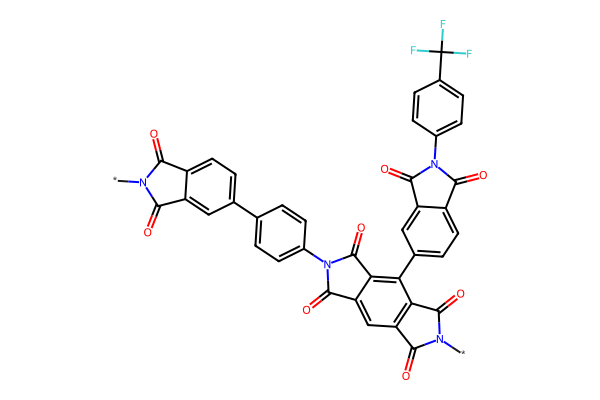


Предсказанные свойства для [*]N1C(=O)c2ccc(-c3ccc(-n4c(=O)c5cc6c(=O)n([*])c(=...:
Group Contribution Energy (kJ/mol)       : 2.3977
Bond Energy Contribution (kJ/mol)        : 1.9448
Internal Bond Energy (kJ/mol)            : 2.5473
Cohesive Energy Density (J/cm³)          : 201.5569
Ionization Energy (eV)                   : 6.0270
Electron Affinity (eV)                   : 3.1943
Atomization Energy (kJ/mol)              : -5.8333
Number of Carbon Atoms                   : 1.9109
Number of Electrons                      : 1.6205
Crystallinity Index (%)                  : 61.5732
Crosslinking Density (mol/m³)            : 52.1912
Dielectric Constant at 6.0 GHz           : 3.2538
Static Dielectric Constant (0 Hz)        : 4.2491
Dielectric Constant at 3.0 GHz           : 3.4159
Dielectric Constant at 1.78 GHz          : 3.6422
Dielectric Constant at 15.0 GHz          : 2.6331
Dielectric Constant at 4.0 GHz           : 3.3440
Dielectric Constant at 5.0 GHz           : 3.3020
Dielectric C

In [39]:
# Загружаем модель
predictor = SmilesPropertyPredictorInference(SAVE_DIR)

# Тестовые данные
test_smiles = [
    "[*]N1C(=O)c2ccc(-c3ccc(-n4c(=O)c5cc6c(=O)n([*])c(=O)c6c(-c6ccc7c(c6)C(=O)N(c6ccc(C(F)(F)F)cc6)C7=O)c5c4=O)cc3)cc2C1=O"
]

# Настройки Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Предсказание с картинкой
results = predictor.predict_with_advanced_visualization(test_smiles)

In [38]:
results

,smiles,Egc,Egb,Eib,CED,Ei,Eea,Eat,nc,ne,Xc,Xe,epse_6.0,epsc,epse_3.0,epse_1.78,epse_15.0,epse_4.0,epse_5.0,epse_2.0,epse_9.0,epse_7.0,epsb,TSb,TSy,YM,permCH4,permCO2,permH2,permO2,permN2,permHe,Cp,Td,Tg,Tm,rho,LOI
0,[*]C(=O)c1ccc(-c2ccc3c(c2)C(=O)N(c2ccc(-c4ccc5...,3.0074,2.3402,2.7907,210.8860,6.4684,3.5096,-6.0172,1.9583,1.6395,45.7419,41.0816,3.5937,4.5082,3.8495,4.0838,2.7030,3.7534,3.6769,4.0264,3.2732,3.4944,10.0452,94.7629,61.1502,2038.3715,0.0615,2.6551,8.9880,0.5783,0.0650,8.7219,1.2766,717.6530,592.1767,661.8595,1.3703,36.3971


In [40]:
def predict_for_dataset(
    predictor, 
    input_path="data/polymers.csv", 
    output_path="data/polymers_predicted.csv", 
    smiles_col="smiles",  # Имя колонки с полимером в CSV
    batch_size=64
):
    print(f"Загрузка данных из {input_path}...")
    df = pd.read_csv(input_path)
    
    # Проверка наличия колонки
    if smiles_col not in df.columns:
        # Пытаемся найти похожую колонку, если точного совпадения нет
        candidates = [c for c in df.columns if 'smiles' in c.lower() and 'mono' not in c.lower()]
        if candidates:
            print(f"Колонка '{smiles_col}' не найдена. Используем '{candidates[0]}'")
            smiles_col = candidates[0]
        else:
            raise ValueError(f"Колонка со SMILES полимера не найдена. Доступные колонки: {df.columns.tolist()}")

    print(f"Найдено записей: {len(df)}")
    
    # Подготовка списков для результатов
    all_predictions = []
    
    # Итерируемся по датасету батчами
    # tqdm создает красивую полосу прогресса
    for i in tqdm(range(0, len(df), batch_size), desc="Предсказание свойств"):
        # Выбираем батч
        batch_smiles = df[smiles_col].iloc[i : i + batch_size].tolist()
        
        # Обработка пустых значений или не строк (на всякий случай)
        clean_batch = []
        valid_indices = [] # Индексы внутри батча, которые валидны
        
        for idx, s in enumerate(batch_smiles):
            if isinstance(s, str) and len(s) > 0:
                clean_batch.append(s)
                valid_indices.append(idx)
            else:
                # Если SMILES пустой, добавляем заглушку, чтобы потом заполнить NaN
                # Но лучше просто пропускать и потом выравнивать
                pass

        if not clean_batch:
            # Если весь батч пустой (странно, но бывает)
            # Создаем пустой DF с нужными колонками
            empty_preds = pd.DataFrame(columns=predictor.property_cols)
            # Заполняем NaN на длину батча
            empty_preds = pd.DataFrame(index=range(len(batch_smiles)), columns=predictor.property_cols)
            all_predictions.append(empty_preds)
            continue

        try:
            # Предсказание через модель
            # Возвращает DF: ['smiles', 'prop1', 'prop2'...]
            preds_df = predictor.predict(clean_batch)
            
            # Нам нужны только колонки со свойствами (без smiles, так как они есть в исходном df)
            prop_cols = [c for c in preds_df.columns if c != 'smiles']
            preds_only_props = preds_df[prop_cols]
            
            # Если в батче были невалидные строки, нужно восстановить размерность
            if len(preds_only_props) != len(batch_smiles):
                # Создаем полный DF для этого батча, заполненный NaN
                full_batch_preds = pd.DataFrame(
                    index=range(len(batch_smiles)), 
                    columns=prop_cols
                )
                # Вставляем предсказанные значения на свои места
                # (Внимание: это упрощенная логика, предполагающая порядок. 
                # predictor.predict возвращает в том же порядке, что и вход)
                full_batch_preds.iloc[valid_indices] = preds_only_props.values
                all_predictions.append(full_batch_preds)
            else:
                all_predictions.append(preds_only_props)
                
        except Exception as e:
            print(f"Ошибка на батче {i}: {e}")
            # В случае ошибки заполняем NaN чтобы не упал весь процесс
            empty_preds = pd.DataFrame(index=range(len(batch_smiles)), columns=predictor.property_cols)
            all_predictions.append(empty_preds)

    print("Объединение результатов...")
    # Собираем все батчи в один большой DataFrame
    all_predictions_df = pd.concat(all_predictions, axis=0).reset_index(drop=True)
    
    # Проверка размерностей перед слиянием
    if len(all_predictions_df) != len(df):
        print(f"ВНИМАНИЕ: Длина предсказаний ({len(all_predictions_df)}) не совпадает с исходной ({len(df)})")
        # Обрезаем или дополняем (крайний случай)
        min_len = min(len(all_predictions_df), len(df))
        all_predictions_df = all_predictions_df.iloc[:min_len]
        df = df.iloc[:min_len]

    # Объединяем исходный датасет с предсказаниями по горизонтали
    # Используем pd.concat([df, preds], axis=1)
    result_df = pd.concat([df.reset_index(drop=True), all_predictions_df], axis=1)
    
    print(f"Сохранение в {output_path}...")
    result_df.to_csv(output_path, index=False)
    print("Готово!")
    return result_df

In [43]:
def correct_negative_values(df, property_cols, epsilon=1e-4):
    """
    Заменяет отрицательные значения в колонках свойств на epsilon.
    
    Args:
        df (pd.DataFrame): Датафрейм с предсказаниями
        property_cols (list): Список колонок со свойствами (ключи из JSON)
        epsilon (float): Значение, которым заменяем отрицательные числа (по умолчанию 0.0001)
    """
    # Создаем копию, чтобы не менять исходный объект, если не нужно
    df_corrected = df.copy()
    
    print(f"Коррекция отрицательных значений (замена на {epsilon})...")
    
    corrected_count = 0
    
    for col in property_cols:
        if col in df_corrected.columns:
            # Маска для отрицательных значений
            mask = df_corrected[col] < 0
            count = mask.sum()
            
            if count > 0:
                # Особая логика для диэлектрической проницаемости (eps)
                # Физически она не может быть меньше 1.0
                if col.startswith('eps') and col != 'epsb': # epsb - это пробой (kV/mm), он мб < 1, но > 0
                     df_corrected.loc[df_corrected[col] < 1.0, col] = 1.0
                else:
                    # Для всего остального ставим epsilon
                    df_corrected.loc[mask, col] = epsilon
                
                corrected_count += count
    
    print(f"Исправлено {corrected_count} ячеек.")
    return df_corrected

In [46]:
df_predicted = pd.read_csv("data/polymers_with_properties.csv")

# 2. Получаем список колонок свойств из вашего маппинга
# (Предполагаем, что PROPERTY_MAPPING загружен, как в начале вашего кода)
property_columns = list(PROPERTY_MAPPING.keys())

# 3. Применяем коррекцию
df_clean = correct_negative_values(df_predicted, property_columns)

# 4. Сохраняем финальную чистую версию
df_clean.to_csv("data/polymers_with_names_predicted.csv", index=False)

# Проверка: смотрим, есть ли отрицательные значения
min_values = df_clean[property_columns].min()
print("\nМинимальные значения после очистки:")
print(min_values.head())

Коррекция отрицательных значений (замена на 0.0001)...
Исправлено 12216 ячеек.

Минимальные значения после очистки:
Egc    1.4966
Egb    1.1728
Eib    2.7795
CED   46.2019
Ei     4.1343
dtype: float64
